In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import scipy.sparse as sparse
from scipy.special import erf

## 1a. 
**Domain:** 0 < x < L. Computation starts one grid point below the surface (node 1 sits at x = dx, not at x = 0 — the surface itself is not a computational node). L is set to 300 km, deep enough that the temperature there stays at its initial value over the timescales we care about.

**Initial condition:** T = 2000°C everywhere.
**Boundary conditions:**
- x = 0 (the surface, just outside the first node): Dirichlet, T = 0°C fixed for all time.
- x = L (far boundary): no-flux (insulated) nothing has diffused that far yet so it doesn't matter much

In [2]:
# --- physical parameters (all SI units) ---
D = 1.2e-6            # thermal diffusivity, m^2/s
T0 = 2000.0           # initial uniform temperature, deg C
T_surface = 0.0       # fixed surface temperature, deg C
target_grad = 25.0 / 1000.0   # measured gradient, 25 C/km -> C/m

sec_per_year = 365.25 * 24 * 3600

## 1b. 
Using m = 150 grid points over the 300 km domain (dx = 2 km). Grid resolution is checked for convergence in part 1e below.

In [3]:
# --- grid ---
m = 150               # number of grid points
L = 3e5               # domain depth, m (300 km -- comfortably deeper than heat can diffuse)
dx = L / m
x = np.linspace(dx, m*dx, m)

# initial condition: uniformly molten
y0 = T0 * np.ones(m)

## 1c. 
Everything is kept in SI units throughout: D in m²/s, distances in meters, time in seconds, target gradient converted from 25°C/km to 0.025°C/m. At the end it is converted back to years (÷ 3.156×10⁷ s/yr).

In [4]:
# --- Laplacian operator with boundary conditions ---
# left (x=0, the surface): Dirichlet, T fixed at T_surface
# right (x=L): no-flux, since the domain is deep enough that nothing has happened there yet
e1 = np.ones((1, m))
diags = np.concatenate((e1, -2.*e1, e1))
offsets = np.array([-1, 0, 1])
A = sparse.dia_matrix((diags, offsets), shape=(m, m)).tolil()
A[-1, -1] = -1.        # no-flux at the far boundary
A = A.tocsr()

b = np.zeros(m)        # surface is fixed at 0, so its ghost-point contribution is 0 too

In [5]:
# --- solve ---
def F(t, y):
    return D * (A.dot(y) + b) / dx**2

t_max = 3e15   # ~95 Myr, comfortably past where we expect the crossing
t_eval = np.linspace(0, t_max, 4000)
sol = solve_ivp(F, [0, t_max], y0, method='BDF', t_eval=t_eval)

t = sol.t
y = sol.y

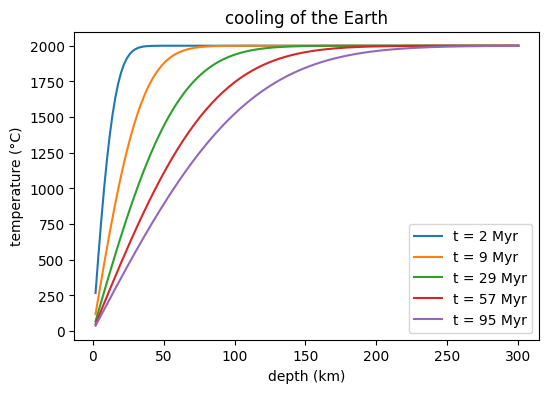

In [6]:
# temperature profile at a few snapshots
fig, ax = plt.subplots(figsize=(6,4))
for frac in [0.02, 0.1, 0.3, 0.6, 1.0]:
    i = int(frac*(len(t)-1))
    ax.plot(x/1000, y[:,i], label=f"t = {t[i]/sec_per_year/1e6:.0f} Myr")
ax.set_xlabel('depth (km)')
ax.set_ylabel('temperature (°C)')
ax.legend()
ax.set_title('cooling of the Earth')
plt.show()

## 1d. 

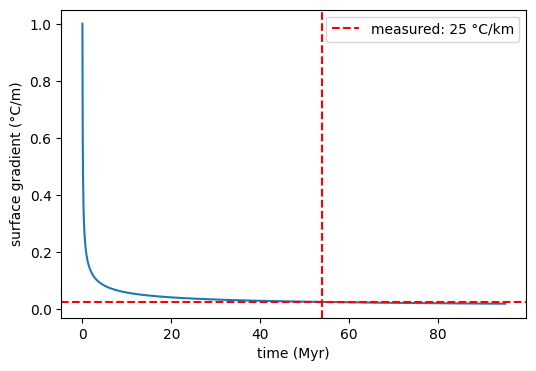

Kelvin's age of the Earth: 53.8 Myr


In [7]:
# surface gradient over time, and when it crosses the measured value
grad = (y[0, :] - T_surface) / dx
idx = np.argmax(grad < target_grad)
age = t[idx]

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(t/sec_per_year/1e6, grad)
ax.axhline(target_grad, color='r', ls='--', label='measured: 25 °C/km')
ax.axvline(age/sec_per_year/1e6, color='r', ls='--')
ax.set_xlabel('time (Myr)')
ax.set_ylabel('surface gradient (°C/m)')
ax.legend()
plt.show()

print(f"Kelvin's age of the Earth: {age/sec_per_year/1e6:.1f} Myr")

**Answer to 1d: 53.8 million years.**

## 1e. 

In [8]:
def kelvin_age(m, L=3e5, t_max=3e15):
    dx = L / m
    y0 = T0 * np.ones(m)
    e1 = np.ones((1, m))
    diags = np.concatenate((e1, -2.*e1, e1))
    A = sparse.dia_matrix((diags, [-1,0,1]), shape=(m, m)).tolil()
    A[-1, -1] = -1.
    A = A.tocsr()
    b = np.zeros(m)

    def F(t, y):
        return D * (A.dot(y) + b) / dx**2

    t_eval = np.linspace(0, t_max, 4000)
    sol = solve_ivp(F, [0, t_max], y0, method='BDF', t_eval=t_eval)
    grad = (sol.y[0, :] - T_surface) / dx
    idx = np.argmax(grad < target_grad)
    return sol.t[idx] / sec_per_year / 1e6

for m_test in [50, 100, 150, 300]:
    print(f"m = {m_test:4d}  ->  age = {kelvin_age(m_test):.2f} Myr")

m =   50  ->  age = 53.72 Myr


m =  100  ->  age = 53.84 Myr


m =  150  ->  age = 53.82 Myr


m =  300  ->  age = 53.84 Myr


**Answer to 1e:** the age barely moves once m is above ~100 (53.7–53.8 Myr across m = 50–300) so the result is converged so using more grid points doesn't change the answer.

## 1f. 
Heat only diffused down to a depth of $\sim\sqrt{Dt}\approx$ which is miniscule compared to Earth's radius. The surface is essentially flat so ignoring the sphere's curvature and treating it as a 1-D half-space is a good approximation. 

## 2.

analytical age: 53.8 Myr  (numerical gave 53.8 Myr)


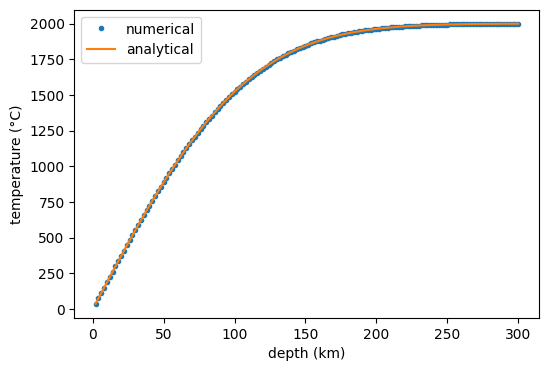

In [9]:
t_grid = np.linspace(1e12, t_max, 200000)
grad_analytic = T0 / np.sqrt(np.pi * D * t_grid)
idx = np.argmax(grad_analytic < target_grad)
age_analytic = t_grid[idx] / sec_per_year / 1e6
print(f"analytical age: {age_analytic:.1f} Myr  (numerical gave {age/sec_per_year/1e6:.1f} Myr)")

# and the profile itself, numeric vs analytic, at the final time
T_analytic = T0 * erf(x / (2*np.sqrt(D*t[-1])))
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(x/1000, y[:,-1], 'o', ms=3, label='numerical')
ax.plot(x/1000, T_analytic, '-', label='analytical')
ax.set_xlabel('depth (km)')
ax.set_ylabel('temperature (°C)')
ax.legend()
plt.show()

**Answer to part 2:** the analytical solution gives essentially the same age and the two temperature profiles align almost exactly confirming the numerical solution is correct.